<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/PL9_Colab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prelab 9.1 Machine Learning 2 - Machine Learning Implementation to Edge Device

## Learning Goals

Students will be able to:

1. Install Pytorch and subsequently load a machine learning (ML) model



## 1.1 Introduction


In Lab 9, we will implement the machine learning model you developed in Lab 8 to Raspberry Pi. Eventually, you will build up an IIoT smart monitoring system from measuring sensor data in real-time to visualize not only the data but also the result of a machine learning model. This prelab is **1) to install PyTorch in Raspberry Pi** and **2) to load the model you finally developed in Lab9.**

## 1.2 PyTorch Installation on Raspberry Pi

To install PyTorch, open ‘Terminal’ on Raspberry Pi and please follow the steps below.

1.	To keep Raspberry Pi packages up to date, run the command lines below.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal**

`sudo apt update`

`sudo apt upgrade -y`

---

<br>


2. Install PyTorch

---
**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal**

`python -m pip install --no-cache-dir --index-url https://download.pytorch.org/whl/cpu torch --break-system-packages`

```
python -c "import torch; print('Torch Version is', torch.__version__)"
```

---

<br>

3. Done! Reboot Raspberry Pi

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal**

`sudo reboot`

---

### Task 1.1

By running the example Python script below, check TensorFlow version as Figure 1 below and then attach it to the report.

---

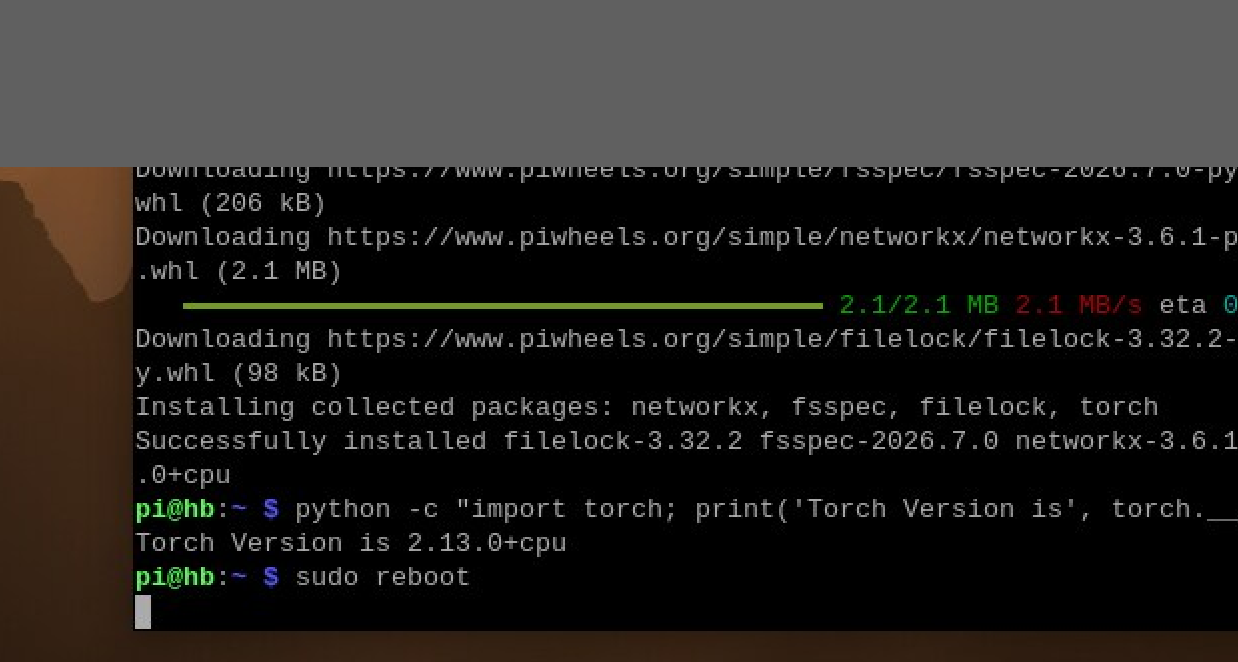

---



**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal & Python**

```
$ python3
>>> import torch
>>> print(“PyTorch version is {}.”.format(torch.__version__))
```

---

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_update_pytorch/Prelab9_fig1.png?raw=tru" width="90%">

*Figure 1 PyTorch version check*

## 1.3 Load Machine Learning Model Using PyTorch on Raspberry Pi

Let’s load the model on Raspberry Pi you finally developed in Lab8. Please follow the steps below.

1.	Make a working directory in which your model and Python file will be.

  a.	The directory example: ‘/home/pi/prelab9/models’

2.	Copy and paste the best model you created in Lab 8 to Raspberry Pi directory
(‘/home/pi/prelab9/models’)

  a.	Check the model is moved to the Raspberry Pi

3.	Create a Python file as ‘prelab9_load_model.py’ on the working directory. In this example, the working directory is ‘/home/pi/prelab9/models/’.

4.	Code the Python script below in the created Python file (‘prelab9_load_model.py’) and then save it.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python3 (prelab9_load_model.py)**

```
import torch
import torch.nn as nn

EMBEDDING_SIZE = 64
N_feature = 1000

class AnomalyDetector(nn.Module):
    def __init__(self, N_feature):
        super(AnomalyDetector, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(N_feature, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, EMBEDDING_SIZE),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(EMBEDDING_SIZE, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, N_feature),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))
        
# device setting
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model path
model_path = r"20260414_220026_lab8_anomaly_x-axis_raw.pth"

# load model
loaded_model = AnomalyDetector(N_feature)
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.to(device)
loaded_model.eval()

print("Model reload success.")

```

---

<br>

Now, you are ready to use the model you created in Lab9 to predict running conditions of the AFF on Raspberry Pi. Perform Task 1.2 to see if the model is loaded successfully. Moreover, it is highly recommended to review the previous labs to build up the entire monitoring system in Lab9.


### Task 1.2

1.	After performing the steps (load the model) above, run the Python file. Is the result as you expected?
2.	Capture the result of Terminal or Shell of Thonny as Figure 2 and attach it to the report.

  ---

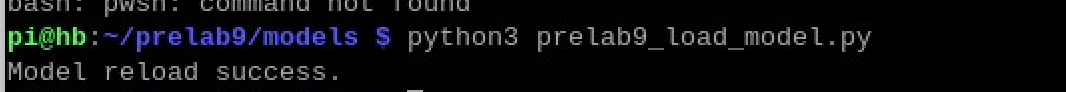

  ---

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_update_pytorch/Prelab9_fig2.png?raw=tru" width="90%">

*Figure 2 Model load*


## (Optional) Play with PyTorch and the Loaded Model

By using the example Python script to load the model and the sample Python scripts in the previous labs, try to run the model by measuring the ADXL345 sensor. In your home setup without attaching the sensor to the AFF, what is the output from the model? Play with the sensor and the model!

### Task 1.3 Using the list below, describe the data flow pipeline (system configuration) and software you need to use in order to realize real-time running condition prediction of the AFF.

  * Sensor: ADXL345
  * Middleware: MTConnect
  * Database: MySQL
  * Visualization: Grafana
  * Monitoring target(s):
     * Time domain features of each axis of the sensor
     * Anomaly prediction results of the AFF



---

Write down your answer to Task 1.3 here. You can use diagrams, figures, and/or descriptions.

---



<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)